In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Data Preparation

In [2]:
df_train = pd.read_csv('train_data.csv') 
df_test = pd.read_csv('test_data.csv')

In [3]:

df_train = df_train.drop(columns=[
     'averageRating', 'originalTitle',  
])

df_test = df_test.drop(columns=[
     'averageRating', 'originalTitle', 
])



In [4]:
my_dict = {
    '(0, 1]': 0,
    '(1, 2]': 0,
    '(2, 3]': 0,
    '(3, 4]': 0,
    '(4, 5]': 1,
    '(5, 6]': 1,
    '(6, 7]': 2,
    '(7, 8]': 3,
    '(8, 9]': 4,
    '(9, 10]': 5,
}
df_train['rating'] = df_train['rating'].map(my_dict)
df_test['rating'] = df_test['rating'].map(my_dict)


In [5]:
X_train = df_train.drop(columns=["rating"]).to_numpy()
y_train = df_train["rating"].to_numpy()
X_test = df_test.drop(columns=["rating"]).to_numpy()
y_test = df_test["rating"].to_numpy()

In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
from collections import Counter

In [10]:
Counter(y_train)

Counter({3: 33619, 2: 27004, 1: 21120, 4: 15332, 0: 3614, 5: 2990})

In [11]:
ctr = Counter(y_train)
ctr

Counter({3: 33619, 2: 27004, 1: 21120, 4: 15332, 0: 3614, 5: 2990})

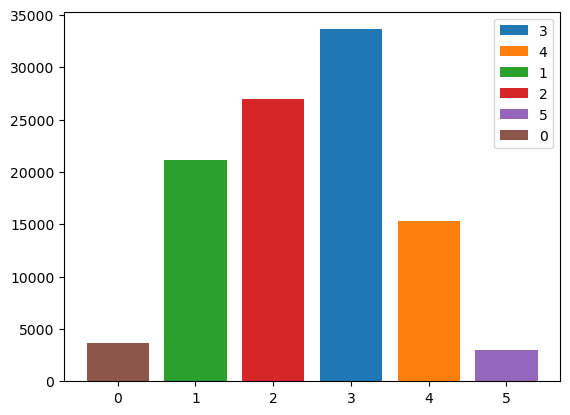

In [14]:
plt.bar(ctr.keys(), ctr.values(), label=ctr.keys(), color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown'])
plt.legend()
plt.show()

# PCA

In [8]:
from sklearn.decomposition import PCA

In [9]:
pca = PCA(n_components=21)
pca.fit(X_train)
X_pca = pca.transform(X_train)

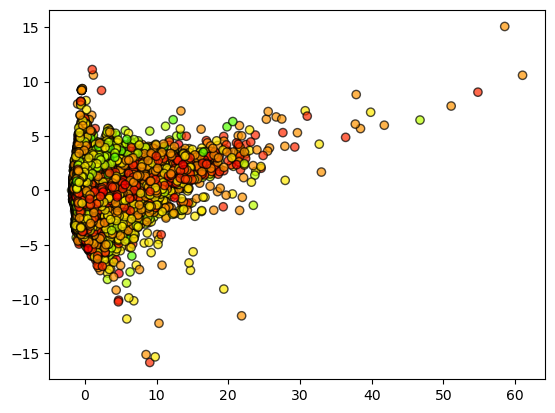

In [10]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()



# Linear SVM

In [11]:
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsOneClassifier

In [12]:

clf = LinearSVC(C=1.0, random_state=42)


clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.3995048947901429
F1-score [0.         0.47557753 0.17839837 0.53419355 0.0030326  0.        ]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1547
           1       0.39      0.62      0.48      9052
           2       0.34      0.12      0.18     11574
           3       0.42      0.75      0.53     14409
           4       0.42      0.00      0.00      6571
           5       0.00      0.00      0.00      1282

    accuracy                           0.40     44435
   macro avg       0.26      0.25      0.20     44435
weighted avg       0.36      0.40      0.32     44435



c:\Users\hiend\miniconda3\envs\corso\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hiend\miniconda3\envs\corso\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hiend\miniconda3\envs\corso\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
clf = LinearSVC(C=100.0, random_state=42,class_weight='balanced')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.3452008551817261
F1-score [0.1277533  0.47075463 0.11985342 0.50316229 0.09054203 0.14978767]
              precision    recall  f1-score   support

           0       0.09      0.21      0.13      1547
           1       0.40      0.57      0.47      9052
           2       0.36      0.07      0.12     11574
           3       0.46      0.56      0.50     14409
           4       0.23      0.06      0.09      6571
           5       0.09      0.45      0.15      1282

    accuracy                           0.35     44435
   macro avg       0.27      0.32      0.24     44435
weighted avg       0.36      0.35      0.31     44435



In [14]:
clf = LinearSVC(C=0.001, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.34693372341622597
F1-score [0.1281483  0.47183131 0.12042486 0.50446373 0.08981595 0.15145937]
              precision    recall  f1-score   support

           0       0.09      0.21      0.13      1547
           1       0.40      0.57      0.47      9052
           2       0.36      0.07      0.12     11574
           3       0.46      0.56      0.50     14409
           4       0.23      0.06      0.09      6571
           5       0.09      0.45      0.15      1282

    accuracy                           0.35     44435
   macro avg       0.27      0.32      0.24     44435
weighted avg       0.36      0.35      0.31     44435



In [15]:
decision_function = clf.decision_function(X_train)
# Use np.any to find rows where margin is violated (multi-class)
support_vector_indices = np.where(np.any(decision_function <= 1, axis=1))[0]
support_vectors = X_train[support_vector_indices]

In [16]:
support_vectors_pca = pca.transform(support_vectors)

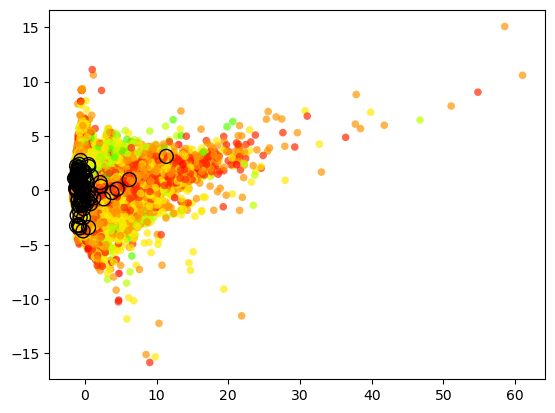

In [17]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='none', alpha=0.7, s=30)
plt.scatter(support_vectors_pca[:100, 0], support_vectors_pca[:100, 1], s=100,
                linewidth=1, facecolors='none', edgecolors='k')
plt.show()

In [18]:
clf.__dict__

{'dual': 'auto',
 'tol': 0.0001,
 'C': 0.001,
 'multi_class': 'ovr',
 'fit_intercept': True,
 'intercept_scaling': 1,
 'class_weight': 'balanced',
 'verbose': 0,
 'random_state': 42,
 'max_iter': 1000,
 'penalty': 'l2',
 'loss': 'squared_hinge',
 'n_features_in_': 21,
 'classes_': array([0, 1, 2, 3, 4, 5], dtype=int64),
 'coef_': array([[ 0.03637256,  0.02853552, -0.05342531, -0.01685693,  0.03222849,
         -0.09882646, -0.01092759, -0.0044518 , -0.00167034,  0.06807559,
         -0.06431445, -0.04118692,  0.01764312, -0.05325462, -0.00459276,
         -0.0142476 , -0.02364703, -0.10341256, -0.04933107, -0.07069991,
          0.02803296],
        [-0.06423783,  0.02742078, -0.01549537,  0.00172768,  0.02625974,
         -0.14110126, -0.06660834,  0.0198891 ,  0.02824507,  0.02173329,
         -0.06472114, -0.00232091,  0.00440911,  0.01233577,  0.03398694,
          0.00812096, -0.00769479, -0.05873811, -0.04541683, -0.05110358,
         -0.02346308],
        [-0.04059484,  0.003243

## Effect of C

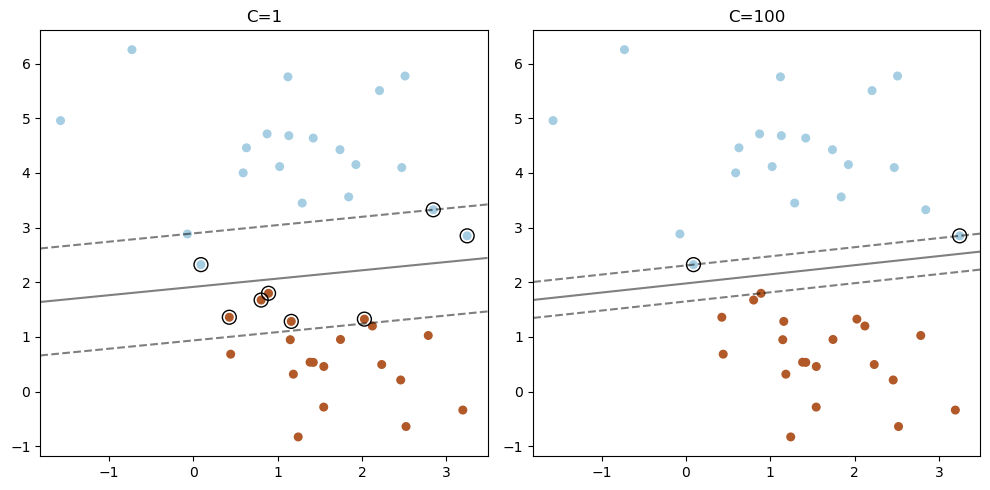

In [19]:
from sklearn.datasets import make_blobs
from sklearn.svm import LinearSVC

X, y = make_blobs(n_samples=40, centers=2, random_state=0)

plt.figure(figsize=(10, 5))
for i, C in enumerate([1, 100]):
    # "hinge" is the standard SVM loss
    clf = LinearSVC(C=C, loss="hinge", random_state=42).fit(X, y)
    # obtain the support vectors through the decision function
    decision_function = clf.decision_function(X)
    # we can also calculate the decision function manually
    # decision_function = np.dot(X, clf.coef_[0]) + clf.intercept_[0]
    support_vector_indices = np.where((2 * y - 1) * decision_function <= 1)[0]
    support_vectors = X[support_vector_indices]

    plt.subplot(1, 2, i + 1)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired)
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 50),
                         np.linspace(ylim[0], ylim[1], 50))
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
                linestyles=['--', '-', '--'])
    plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s=100,
                linewidth=1, facecolors='none', edgecolors='k')
    plt.title("C=" + str(C))
    #plt.scatter(clf.coef_[:, 0] + clf.intercept_, clf.coef_[:, 1] + clf.intercept_)
plt.tight_layout()
plt.show()

# Nonlinear SVM

In [20]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [21]:
from sklearn.model_selection import RandomizedSearchCV

In [22]:
from sklearn.model_selection import StratifiedKFold

In [ ]:
# Parameter grid to search
param_list = {
    'C': [0.01, 0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel': ['poly'],}
 
clf = SVC(class_weight='balanced')
# Grid search with cross-validation
random_search = RandomizedSearchCV(estimator=clf, param_distributions=param_list, n_iter=24, 
                                   cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42))

random_search.fit(X_train, y_train)

In [ ]:
print("Best parameters found: ", random_search.best_params_)

In [ ]:
y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

In [ ]:
clf = SVC(gamma='auto', C=1, kernel='poly', degree=2, class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.279981996174187
F1-score [0.16351761 0.41638304 0.14450577 0.41543646 0.19650655 0.12982901]
              precision    recall  f1-score   support

           0       0.10      0.45      0.16      1547
           1       0.44      0.40      0.42      9052
           2       0.42      0.09      0.14     11574
           3       0.49      0.36      0.42     14409
           4       0.23      0.17      0.20      6571
           5       0.07      0.64      0.13      1282

    accuracy                           0.28     44435
   macro avg       0.29      0.35      0.24     44435
weighted avg       0.40      0.28      0.30     44435



In [ ]:
clf.support_

array([    62,     87,    238, ..., 103588, 103631, 103674])

In [ ]:
support_vectors_pca = pca.transform(clf.support_vectors_) #[:10]

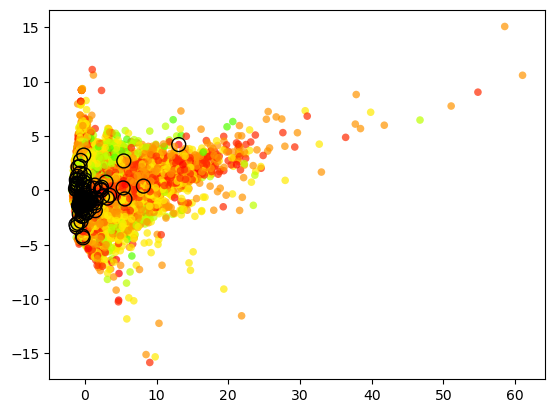

In [ ]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, 
            cmap=plt.cm.prism, edgecolor='none', alpha=0.7, s=30)
plt.scatter(support_vectors_pca[:100, 0], support_vectors_pca[:100, 1], s=100,
                linewidth=1, facecolors='none', edgecolors='k')
plt.show()

In [ ]:
clf.n_support_, len(X_train)

(array([ 3348, 20759, 26753, 33473, 15262,  2667]), 103679)